## Level 5 Sensitivity Analysis: Full System (30 Parameters)

Morris screening to identify the most important parameters across all levels:
- **Level 1**: Metal diffusivity & solubility (Arrhenius)
- **Level 2**: Oxide barrier properties
- **Level 3**: Oxide defect paths
- **Level 4**: Metal microstructure (GB + trapping)

In [1]:
from SALib.sample import morris as morris_sampler
from SALib.analyze import morris as morris_analyzer
from SALib.plotting import morris as morris_plotter
from SALib.sample import saltelli as sobol_sampler
from SALib.analyze import sobol as sobol_analyzer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys


# Add parent directory to path
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
# =============================================================================
# LEVEL 5 SENSITIVITY ANALYSIS SETUP
# =============================================================================

from validation.sensitivity_level1 import (
    morris_sensitivity_level5,
    sobol_sensitivity_level5,
    plot_morris_results,
    plot_sobol_results,
    SUGGESTED_RANGES_LEVEL5,
    DEFAULT_PARAMS_LEVEL5,
    VALID_OUTPUT_METRICS_L5
)

# Check what we have
print(f"Number of parameters in SUGGESTED_RANGES_LEVEL5: {len(SUGGESTED_RANGES_LEVEL5)}")
print(f"\nParameters:")
for i, (param, bounds) in enumerate(SUGGESTED_RANGES_LEVEL5.items(), 1):
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]")

print(f"\nValid output metrics: {VALID_OUTPUT_METRICS_L5}")

Number of parameters in SUGGESTED_RANGES_LEVEL5: 27

Parameters:
   1. D_0                      : [1.00e-08, 1.00e-05]
   2. E_D                      : [4.00e+04, 7.00e+04]
   3. K_s0                     : [1.00e-10, 1.00e-07]
   4. H_s                      : [-4.00e+04, 0.00e+00]
   5. metal_thickness          : [5.00e-04, 5.00e-03]
   6. P_upstream               : [1.00e+03, 1.00e+06]
   7. D_ox_0                   : [1.00e-08, 1.00e-04]
   8. E_D_ox                   : [1.20e+05, 2.00e+05]
   9. K_ox_0                   : [1.00e-06, 1.00e-02]
  10. H_sol_ox                 : [1.50e+05, 2.20e+05]
  11. oxide_thickness          : [1.00e-08, 1.00e-05]
  12. defect_fraction          : [1.00e-04, 1.00e-01]
  13. crack_thickness_factor   : [1.00e-02, 5.00e-01]
  14. gb_diffusivity_factor    : [1.00e+00, 1.00e+02]
  15. grain_size               : [1.00e-07, 1.00e-04]
  16. gb_thickness             : [3.00e-10, 1.00e-09]
  17. gb_enhancement_factor    : [1.00e+01, 1.00e+03]
  18. lattice_de

In [3]:
# =============================================================================
# SETUP - RUN ONCE AFTER KERNEL RESTART
# =============================================================================
import numpy as np
import random
import importlib

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Force reload of modules
import validation.sensitivity_level1 as sens_module
importlib.reload(sens_module)

# Import everything needed
from validation.sensitivity_level1 import (
    morris_sensitivity_level5,
    sobol_sensitivity_level5,
    plot_morris_results,
    plot_sobol_results,
    SUGGESTED_RANGES_LEVEL5,
    DEFAULT_PARAMS_LEVEL5,
    VALID_OUTPUT_METRICS_L5
)

print("✓ Setup complete")
print(f"  Parameters: {len(SUGGESTED_RANGES_LEVEL5)}")
print(f"  Output metrics: {VALID_OUTPUT_METRICS_L5}")

✓ Setup complete
  Parameters: 27
  Output metrics: ['flux', 'PRF', 'D_eff', 'D_modification', 'permeability', 'P_interface', 'flux_intact', 'flux_defect']


In [4]:
# =============================================================================
# MORRIS ANALYSIS: ALL VALID OUTPUT METRICS
# =============================================================================
# Run Morris screening for each output metric and store results

morris_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'#'*70}")
    print(f"# Running Morris for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = morris_sensitivity_level5(
        SUGGESTED_RANGES_LEVEL5,
        N_trajectories=500,
        num_levels=4,
        seed=42,
        output_metric=output_metric
        
    )
    
    morris_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }
    
print("\n" + "="*70)
print("✓ Morris analysis complete for all output metrics!")
print("="*70)


######################################################################
# Running Morris for: flux
######################################################################

MORRIS SENSITIVITY ANALYSIS - LEVEL 5 (Complete Hierarchical Model)
Running 14000 Morris samples...
Parameters (27): D_0, E_D, K_s0, H_s, metal_thickness, P_upstream, D_ox_0, E_D_ox, K_ox_0, H_sol_ox, oxide_thickness, defect_fraction, crack_thickness_factor, gb_diffusivity_factor, grain_size, gb_thickness, gb_enhancement_factor, lattice_density, sites_per_area, trap_dislocation_E_b, trap_dislocation_N_T, trap_gb_E_b, trap_vacancy_E_b, trap_vacancy_N_T, trap_carbide_E_b, trap_carbide_N_T, temperature
Output metric: flux



/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 806.3 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1951: UserWarning: GB traps already in trap_list, not adding automatically
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.01×) and trapping (0.85×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)


  Completed 10/14000 samples
  Completed 20/14000 samples
  Completed 30/14000 samples
  Completed 40/14000 samples
  Completed 50/14000 samples
  Completed 60/14000 samples
  Completed 70/14000 samples
  Completed 80/14000 samples
  Completed 90/14000 samples
  Completed 100/14000 samples
  Completed 110/14000 samples
  Completed 120/14000 samples
  Completed 130/14000 samples
  Completed 140/14000 samples
  Completed 150/14000 samples
  Completed 160/14000 samples
  Completed 170/14000 samples
  Completed 180/14000 samples
  Completed 190/14000 samples
  Completed 200/14000 samples
  Completed 210/14000 samples
  Completed 220/14000 samples
  Completed 230/14000 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.99×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.01×) and trapping (0.97×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (1.00×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.04×) and trapping (0.97×) nearly cancel. Small parameter c

  Completed 240/14000 samples
  Completed 250/14000 samples
  Completed 260/14000 samples
  Completed 270/14000 samples
  Completed 280/14000 samples
  Completed 290/14000 samples
  Completed 300/14000 samples
  Completed 310/14000 samples
  Completed 320/14000 samples
  Completed 330/14000 samples
  Completed 340/14000 samples
  Completed 350/14000 samples
  Completed 360/14000 samples
  Completed 370/14000 samples
  Completed 380/14000 samples
  Completed 390/14000 samples
  Completed 400/14000 samples
  Completed 410/14000 samples
  Completed 420/14000 samples
  Completed 430/14000 samples
  Completed 440/14000 samples
  Completed 450/14000 samples
  Completed 460/14000 samples
  Completed 470/14000 samples
  Completed 480/14000 samples
  Completed 490/14000 samples
  Completed 500/14000 samples
  Completed 510/14000 samples
  Completed 520/14000 samples
  Completed 530/14000 samples


...

  Completed 12300/14000 samples
  Completed 12310/14000 samples
  Completed 12320/14000 samples
  Completed 12330/14000 samples
  Completed 12340/14000 samples
  Completed 12350/14000 samples
  Completed 12360/14000 samples
  Completed 12370/14000 samples
  Completed 12380/14000 samples
  Completed 12390/14000 samples
  Completed 12400/14000 samples
  Completed 12410/14000 samples
  Completed 12420/14000 samples
  Completed 12430/14000 samples
  Completed 12440/14000 samples
  Completed 12450/14000 samples
  Completed 12460/14000 samples
  Completed 12470/14000 samples
  Completed 12480/14000 samples
  Completed 12490/14000 samples
  Completed 12500/14000 samples
  Completed 12510/14000 samples
  Completed 12520/14000 samples
  Completed 12530/14000 samples
  Completed 12540/14000 samples
  Completed 12550/14000 samples
  Completed 12560/14000 samples
  Completed 12570/14000 samples
  Completed 12580/14000 samples
  Completed 12590/14000 samples
  Completed 12600/14000 samples
  Comple

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.03×) and trapping (0.93×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)


  Completed 13280/14000 samples
  Completed 13290/14000 samples
  Completed 13300/14000 samples
  Completed 13310/14000 samples
  Completed 13320/14000 samples
  Completed 13330/14000 samples
  Completed 13340/14000 samples
  Completed 13350/14000 samples
  Completed 13360/14000 samples
  Completed 13370/14000 samples
  Completed 13380/14000 samples
  Completed 13390/14000 samples
  Completed 13400/14000 samples
  Completed 13410/14000 samples
  Completed 13420/14000 samples
  Completed 13430/14000 samples
  Completed 13440/14000 samples
  Completed 13450/14000 samples
  Completed 13460/14000 samples
  Completed 13470/14000 samples
  Completed 13480/14000 samples
  Completed 13490/14000 samples
  Completed 13500/14000 samples
  Completed 13510/14000 samples
  Completed 13520/14000 samples
  Completed 13530/14000 samples
  Completed 13540/14000 samples
  Completed 13550/14000 samples
  Completed 13560/14000 samples
  Completed 13570/14000 samples
  Completed 13580/14000 samples
  Comple

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 8.87e-04 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "


  Completed 13680/14000 samples
  Completed 13690/14000 samples
  Completed 13700/14000 samples
  Completed 13710/14000 samples
  Completed 13720/14000 samples
  Completed 13730/14000 samples
  Completed 13740/14000 samples
  Completed 13750/14000 samples
  Completed 13760/14000 samples
  Completed 13770/14000 samples
  Completed 13780/14000 samples
  Completed 13790/14000 samples
  Completed 13800/14000 samples
  Completed 13810/14000 samples
  Completed 13820/14000 samples
  Completed 13830/14000 samples
  Completed 13840/14000 samples
  Completed 13850/14000 samples
  Completed 13860/14000 samples
  Completed 13870/14000 samples
  Completed 13880/14000 samples
  Completed 13890/14000 samples
  Completed 13900/14000 samples
  Completed 13910/14000 samples
  Completed 13920/14000 samples
  Completed 13930/14000 samples
  Completed 13940/14000 samples
  Completed 13950/14000 samples
  Completed 13960/14000 samples
  Completed 13970/14000 samples
  Completed 13980/14000 samples
  Comple

In [5]:
morris_results

{'flux': {'Si': {'names': array(['D_0', 'E_D', 'K_s0', 'H_s', 'metal_thickness', 'P_upstream',
          'D_ox_0', 'E_D_ox', 'K_ox_0', 'H_sol_ox', 'oxide_thickness',
          'defect_fraction', 'crack_thickness_factor',
          'gb_diffusivity_factor', 'grain_size', 'gb_thickness',
          'gb_enhancement_factor', 'lattice_density', 'sites_per_area',
          'trap_dislocation_E_b', 'trap_dislocation_N_T', 'trap_gb_E_b',
          'trap_vacancy_E_b', 'trap_vacancy_N_T', 'trap_carbide_E_b',
          'trap_carbide_N_T', 'temperature'], dtype='<U22'),
   'mu': masked_array(data=[1.7337719875387413e-09, -2.7488394831309265e-09,
                      2.985212437096747e-09, -2.659619709027396e-09,
                      -1.3117026671129904e-09, 3.6817233588653105e-09,
                      5.102171745657516e-10, -8.310744823949063e-10,
                      3.248273810138794e-10, -1.1221306821097652e-09,
                      -6.534259710963409e-10, 3.0233435799369335e-09, 0.0,
       


OUTPUT: flux


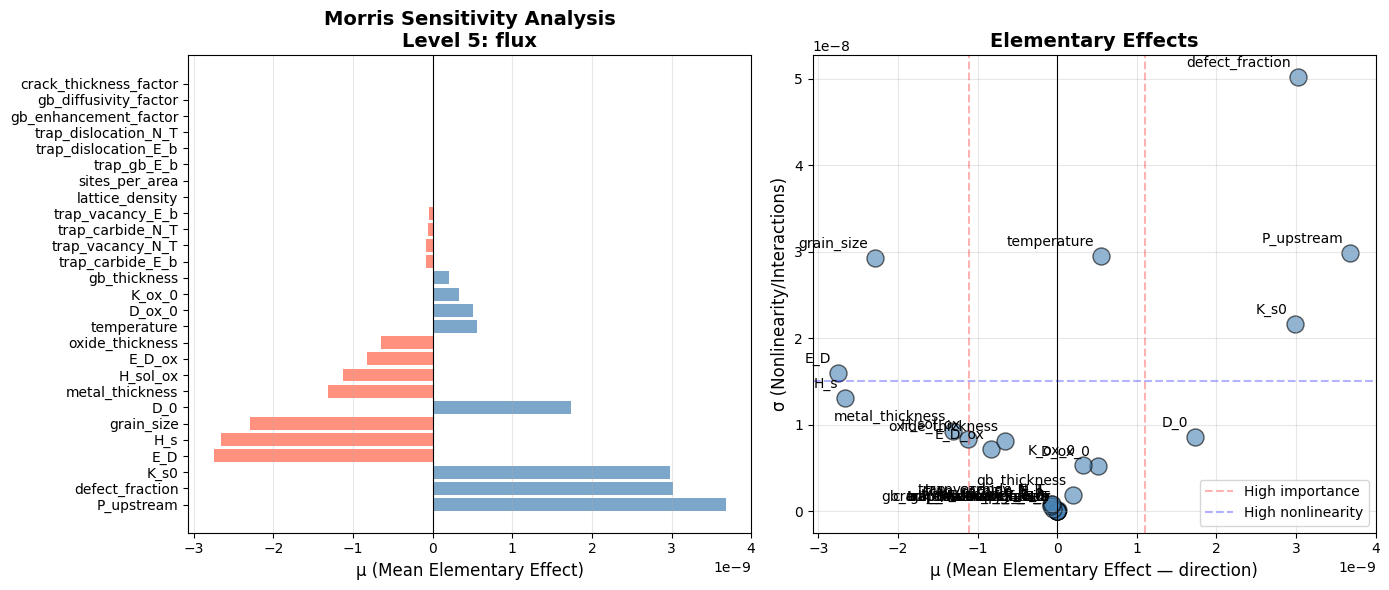


MORRIS SENSITIVITY RESULTS - Level 5: flux
             Parameter             μ            σ       μ_conf
            P_upstream  3.681723e-09 2.981717e-08 2.665654e-09
       defect_fraction  3.023344e-09 5.022705e-08 4.402929e-09
                  K_s0  2.985212e-09 2.165113e-08 1.875116e-09
                   E_D -2.748839e-09 1.593194e-08 1.514123e-09
                   H_s -2.659620e-09 1.310029e-08 1.177243e-09
            grain_size -2.288549e-09 2.930932e-08 2.186949e-09
                   D_0  1.733772e-09 8.570289e-09 7.163626e-10
       metal_thickness -1.311703e-09 9.288650e-09 7.187530e-10
              H_sol_ox -1.122131e-09 8.341076e-09 6.552129e-10
                E_D_ox -8.310745e-10 7.174493e-09 6.020481e-10
       oxide_thickness -6.534260e-10 8.077439e-09 7.116655e-10
           temperature  5.520460e-10 2.956206e-08 2.631927e-09
                D_ox_0  5.102172e-10 5.240862e-09 4.544230e-10
                K_ox_0  3.248274e-10 5.302491e-09 3.987419e-10
          g

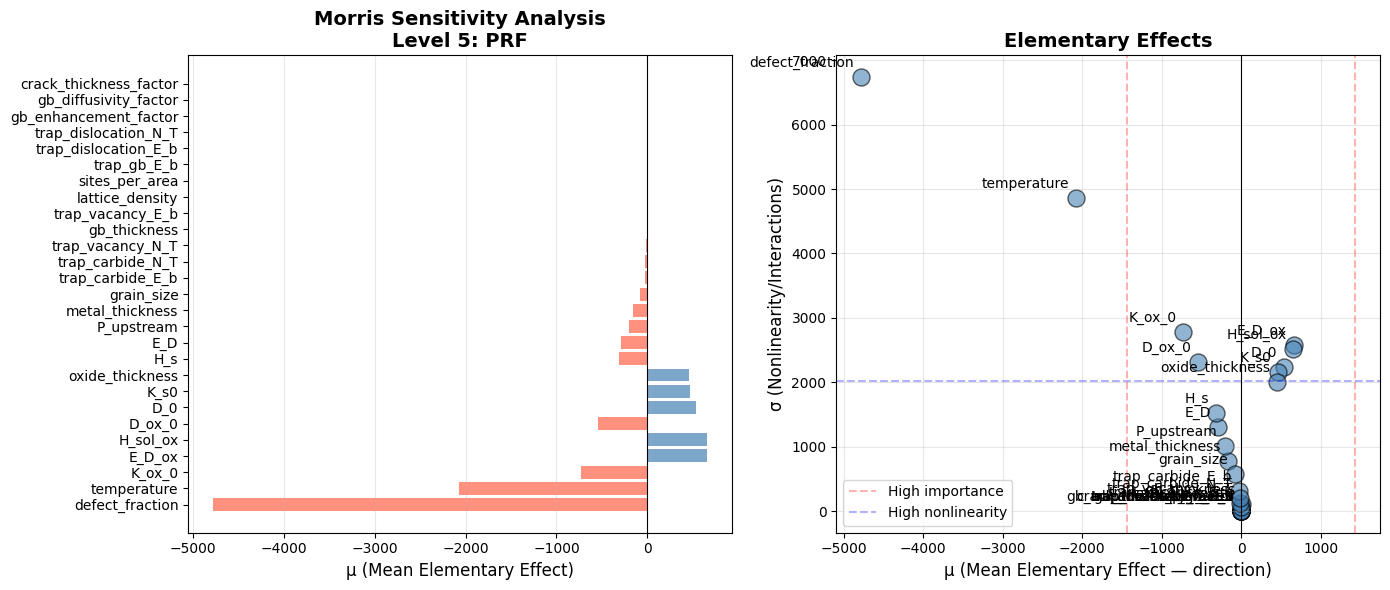


MORRIS SENSITIVITY RESULTS - Level 5: PRF
             Parameter             μ            σ       μ_conf
       defect_fraction -4.782331e+03 6.740029e+03 5.736985e+02
           temperature -2.073212e+03 4.854714e+03 4.208331e+02
                K_ox_0 -7.274997e+02 2.787212e+03 2.649135e+02
                E_D_ox  6.608007e+02 2.574594e+03 2.130691e+02
              H_sol_ox  6.576629e+02 2.511110e+03 2.347505e+02
                D_ox_0 -5.401209e+02 2.309098e+03 1.599168e+02
                   D_0  5.350887e+02 2.230045e+03 1.971583e+02
                  K_s0  4.668478e+02 2.153846e+03 1.935345e+02
       oxide_thickness  4.557252e+02 2.007655e+03 1.806680e+02
                   H_s -3.113342e+02 1.520351e+03 1.145152e+02
                   E_D -2.860097e+02 1.302049e+03 1.162771e+02
            P_upstream -2.064871e+02 1.012795e+03 9.088533e+01
       metal_thickness -1.625512e+02 7.840410e+02 7.039539e+01
            grain_size -8.043017e+01 5.718231e+02 5.326075e+01
      trap_c

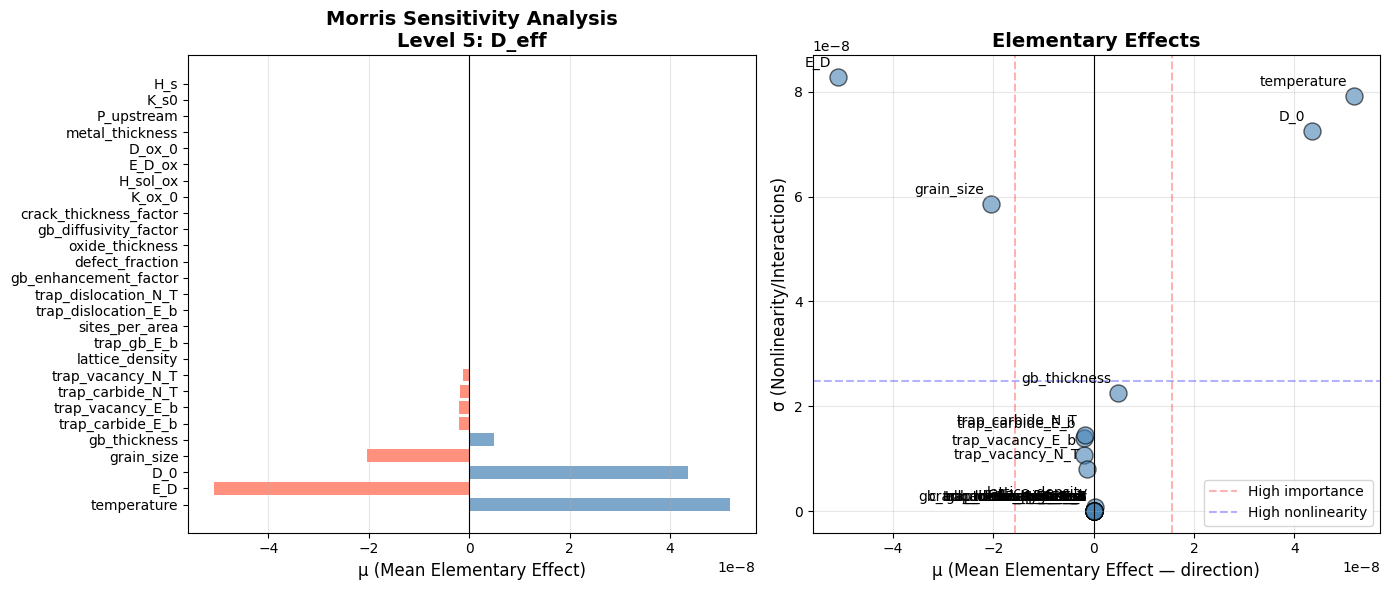


MORRIS SENSITIVITY RESULTS - Level 5: D_eff
             Parameter             μ            σ       μ_conf
           temperature  5.192881e-08 7.917393e-08 6.138506e-09
                   E_D -5.084593e-08 8.285128e-08 7.599157e-09
                   D_0  4.357319e-08 7.253134e-08 6.473730e-09
            grain_size -2.040723e-08 5.859021e-08 4.622278e-09
          gb_thickness  4.890294e-09 2.245354e-08 2.099054e-09
      trap_carbide_E_b -2.005141e-09 1.399257e-08 1.318734e-09
      trap_vacancy_E_b -1.932127e-09 1.074285e-08 1.067541e-09
      trap_carbide_N_T -1.759795e-09 1.458197e-08 1.433715e-09
      trap_vacancy_N_T -1.311766e-09 7.971020e-09 6.794312e-10
       lattice_density  2.590202e-10 8.189601e-10 7.378797e-11
           trap_gb_E_b -6.753989e-18 3.155355e-17 2.800844e-18
        sites_per_area -5.190059e-18 2.868374e-17 2.517204e-18
  trap_dislocation_E_b -6.446530e-19 2.965947e-18 2.511124e-19
  trap_dislocation_N_T -4.375856e-19 1.563389e-18 1.593306e-19
 gb_enhanc

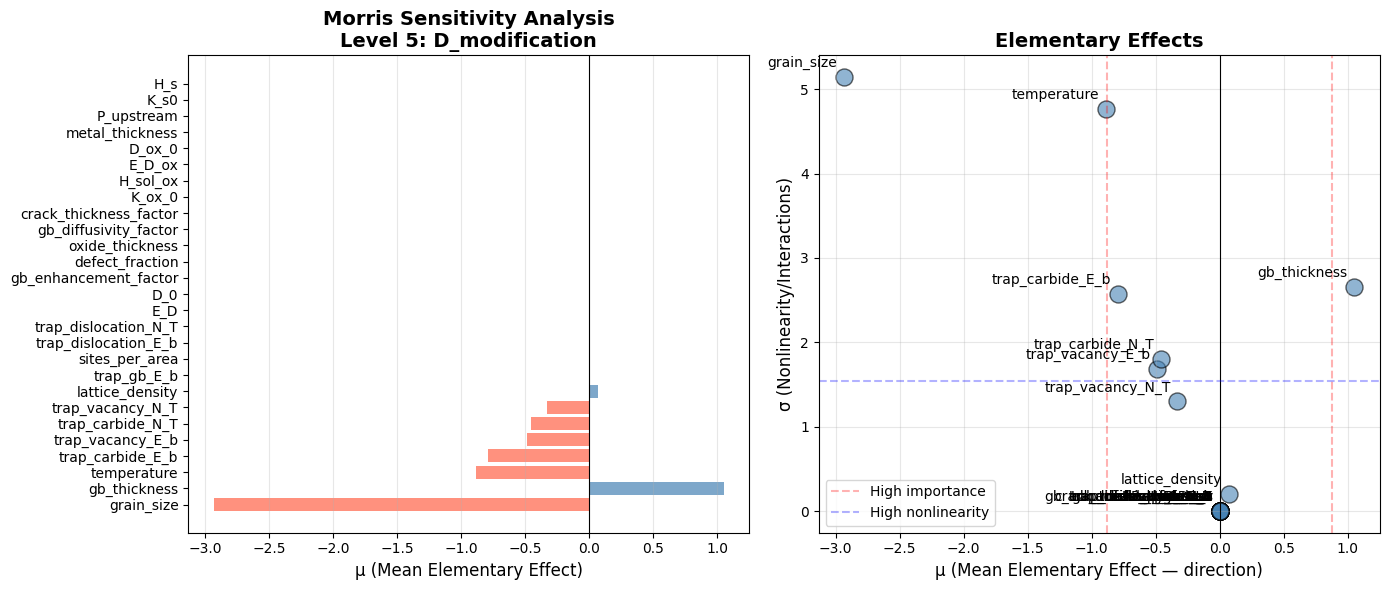


MORRIS SENSITIVITY RESULTS - Level 5: D_modification
             Parameter             μ            σ       μ_conf
            grain_size -2.932449e+00 5.144304e+00 4.397054e-01
          gb_thickness  1.051602e+00 2.656563e+00 2.478159e-01
           temperature -8.864189e-01 4.765213e+00 3.663909e-01
      trap_carbide_E_b -7.914260e-01 2.567683e+00 2.423890e-01
      trap_vacancy_E_b -4.878156e-01 1.678382e+00 1.452401e-01
      trap_carbide_N_T -4.577751e-01 1.798297e+00 1.669914e-01
      trap_vacancy_N_T -3.306423e-01 1.298542e+00 1.150989e-01
       lattice_density  7.189324e-02 2.020207e-01 1.807587e-02
           trap_gb_E_b -6.757407e-09 4.970767e-08 4.522528e-09
        sites_per_area -5.375858e-09 6.267863e-08 6.280798e-09
  trap_dislocation_E_b -1.708032e-10 6.904961e-10 6.271977e-11
  trap_dislocation_N_T -1.013803e-10 4.085631e-10 4.325297e-11
                   E_D  5.652412e-17 8.060945e-16 6.574741e-17
                   D_0 -4.453274e-17 1.100041e-15 9.639132e-17
 

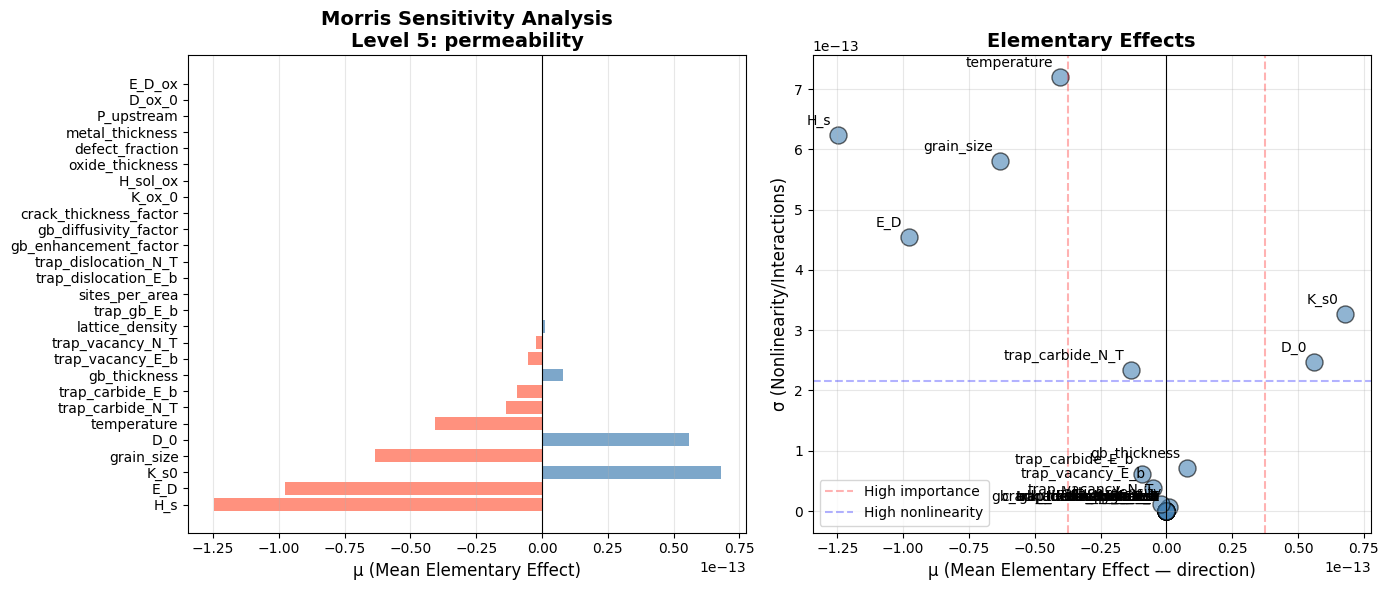


MORRIS SENSITIVITY RESULTS - Level 5: permeability
             Parameter             μ            σ       μ_conf
                   H_s -1.247454e-13 6.236267e-13 5.277868e-14
                   E_D -9.778384e-14 4.550943e-13 3.556172e-14
                  K_s0  6.791693e-14 3.268379e-13 3.139145e-14
            grain_size -6.341149e-14 5.805872e-13 4.884214e-14
                   D_0  5.592141e-14 2.477575e-13 2.026831e-14
           temperature -4.046241e-14 7.200023e-13 5.466315e-14
      trap_carbide_N_T -1.350531e-14 2.339783e-13 2.057483e-14
      trap_carbide_E_b -9.474521e-15 6.124652e-14 5.165144e-15
          gb_thickness  7.901054e-15 7.107425e-14 6.438147e-15
      trap_vacancy_E_b -5.198662e-15 3.759333e-14 2.976565e-15
      trap_vacancy_N_T -2.091033e-15 1.130353e-14 9.194872e-16
       lattice_density  1.006160e-15 6.702143e-15 5.671036e-16
           trap_gb_E_b -2.637881e-23 2.648076e-22 2.243894e-23
        sites_per_area -1.293277e-23 1.754302e-22 1.542997e-23
  t

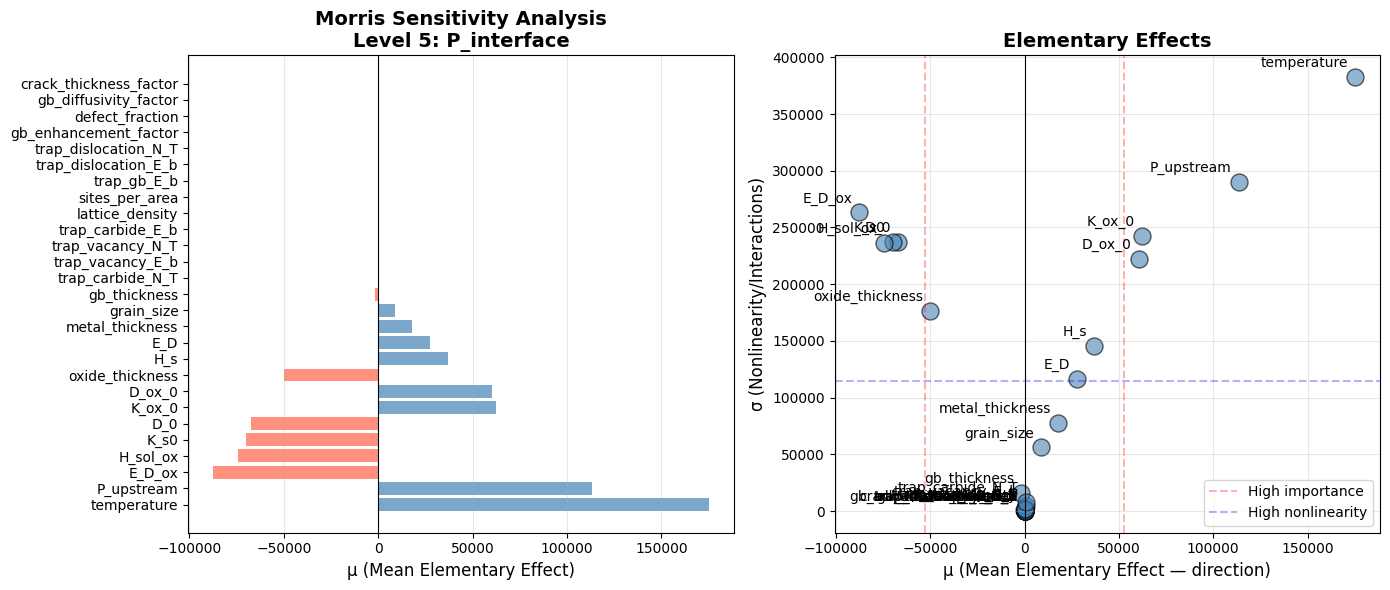


MORRIS SENSITIVITY RESULTS - Level 5: P_interface
             Parameter             μ            σ       μ_conf
           temperature  1.752282e+05 3.826549e+05 3.526999e+04
            P_upstream  1.134928e+05 2.897233e+05 2.610492e+04
                E_D_ox -8.753284e+04 2.632172e+05 2.214618e+04
              H_sol_ox -7.421606e+04 2.360965e+05 2.187610e+04
                  K_s0 -6.993331e+04 2.374634e+05 2.010908e+04
                   D_0 -6.719943e+04 2.373248e+05 2.036428e+04
                K_ox_0  6.217256e+04 2.428144e+05 1.946337e+04
                D_ox_0  6.043728e+04 2.222538e+05 2.116595e+04
       oxide_thickness -5.007545e+04 1.766397e+05 1.608767e+04
                   H_s  3.690177e+04 1.454767e+05 1.235737e+04
                   E_D  2.763980e+04 1.160239e+05 1.041532e+04
       metal_thickness  1.778247e+04 7.731678e+04 6.736538e+03
            grain_size  8.879905e+03 5.603797e+04 5.262954e+03
          gb_thickness -1.669151e+03 1.551480e+04 1.423925e+03
    

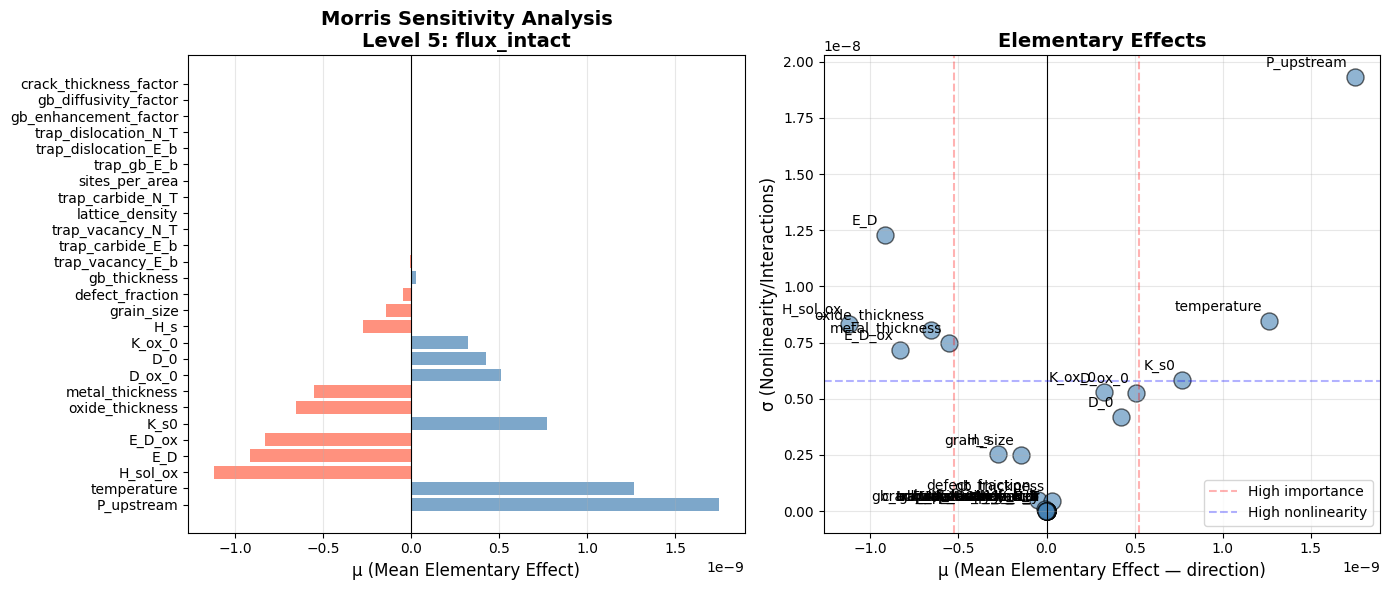


MORRIS SENSITIVITY RESULTS - Level 5: flux_intact
             Parameter             μ            σ       μ_conf
            P_upstream  1.749676e-09 1.932113e-08 1.560898e-09
           temperature  1.264117e-09 8.442706e-09 8.256158e-10
              H_sol_ox -1.122131e-09 8.341076e-09 7.756698e-10
                   E_D -9.163061e-10 1.227572e-08 1.187191e-09
                E_D_ox -8.310745e-10 7.174493e-09 6.323949e-10
                  K_s0  7.708454e-10 5.827534e-09 4.858072e-10
       oxide_thickness -6.534260e-10 8.077439e-09 7.106191e-10
       metal_thickness -5.512740e-10 7.469808e-09 7.516984e-10
                D_ox_0  5.102172e-10 5.240862e-09 4.654223e-10
                   D_0  4.228626e-10 4.185755e-09 3.696375e-10
                K_ox_0  3.248274e-10 5.302491e-09 4.670705e-10
                   H_s -2.761346e-10 2.533969e-09 2.436897e-10
            grain_size -1.429301e-10 2.480460e-09 1.827833e-10
       defect_fraction -4.906551e-11 4.920819e-10 4.627417e-11
    

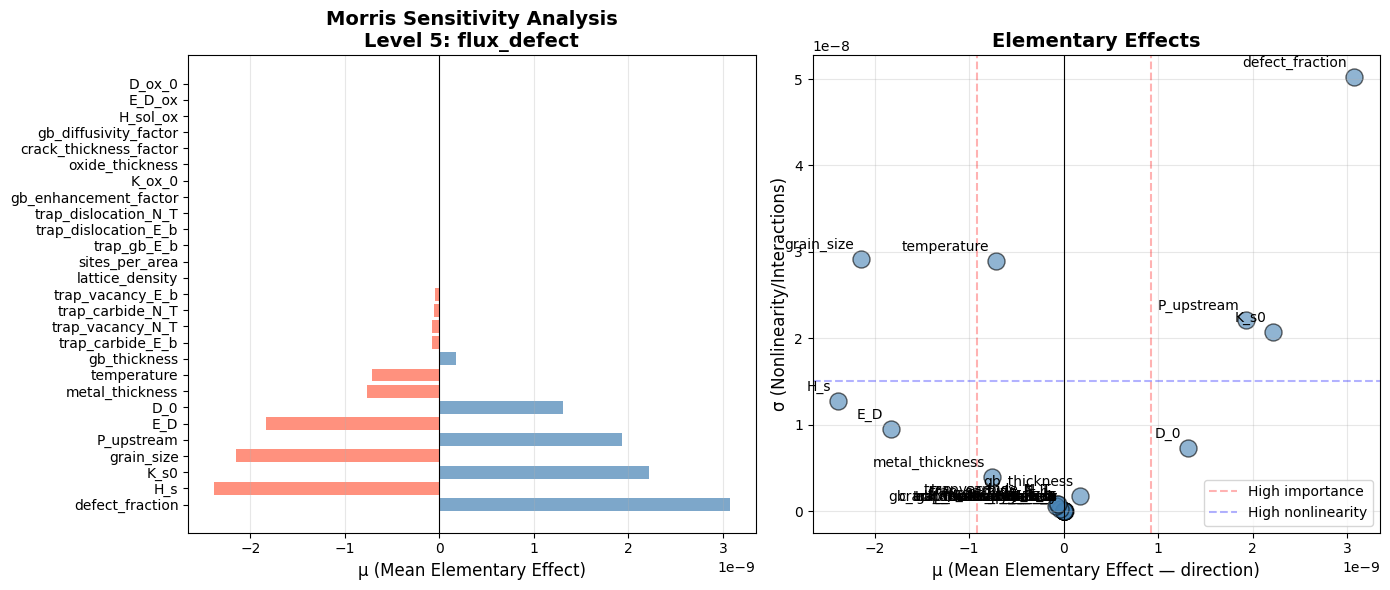


MORRIS SENSITIVITY RESULTS - Level 5: flux_defect
             Parameter             μ            σ       μ_conf
       defect_fraction  3.072409e-09 5.022853e-08 4.781383e-09
                   H_s -2.383485e-09 1.275820e-08 9.674079e-10
                  K_s0  2.214367e-09 2.075451e-08 1.875981e-09
            grain_size -2.145619e-09 2.917660e-08 2.809275e-09
            P_upstream  1.932048e-09 2.210284e-08 1.921878e-09
                   E_D -1.832533e-09 9.462322e-09 8.794708e-10
                   D_0  1.310909e-09 7.270743e-09 6.103569e-10
       metal_thickness -7.604287e-10 3.889966e-09 3.621875e-10
           temperature -7.120708e-10 2.889256e-08 2.267267e-09
          gb_thickness  1.726304e-10 1.735064e-09 1.577622e-10
      trap_carbide_E_b -8.080828e-11 6.278885e-10 4.640672e-11
      trap_vacancy_N_T -7.675388e-11 7.874225e-10 6.480384e-11
      trap_carbide_N_T -6.103077e-11 7.858511e-10 7.322526e-11
      trap_vacancy_E_b -4.328498e-11 2.569569e-10 2.450146e-11
    

In [6]:
# =============================================================================
# PLOT MORRIS RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = morris_results[output_metric]['Si']
    problem = morris_results[output_metric]['problem']
    
    plot_morris_results(Si, problem, f'Level 5: {output_metric}')

In [7]:
# =============================================================================
# PARAMETER IMPORTANCE RANKING ACROSS ALL 8 OUTPUTS
# =============================================================================
import pandas as pd

param_names = morris_results['flux']['problem']['names']

# Build DataFrame with μ for each output
df_all = pd.DataFrame({'Parameter': param_names})

for output_metric in VALID_OUTPUT_METRICS_L5:
    df_all[f'μ_{output_metric}'] = morris_results[output_metric]['Si']['mu']

# Normalize each column
for output_metric in VALID_OUTPUT_METRICS_L5:
    col = f'μ_{output_metric}'
    max_val = df_all[col].abs().max()
    if max_val > 0:
        df_all[f'{col}_norm'] = df_all[col] / max_val
    else:
        df_all[f'{col}_norm'] = 0

# Average normalized importance across all outputs
norm_cols = [f'μ_{m}_norm' for m in VALID_OUTPUT_METRICS_L5]
df_all['Avg_Importance'] = df_all[norm_cols].mean(axis=1)
df_all = df_all.sort_values('Avg_Importance', ascending=False)

# Display summary
print("="*100)
print("PARAMETER IMPORTANCE RANKING (Morris μ - All 8 Outputs)")
print("="*100)
display_cols = ['Parameter'] + [f'μ_{m}' for m in VALID_OUTPUT_METRICS_L5] + ['Avg_Importance']
print(df_all[display_cols].to_string(index=False))
print("="*100)

# Top 10 for Sobol
top_10 = df_all.head(10)['Parameter'].tolist()
print(f"\n→ Top 10 parameters for focused Sobol analysis:")
for i, p in enumerate(top_10, 1):
    importance = df_all[df_all['Parameter'] == p]['Avg_Importance'].values[0]
    print(f"   {i:2d}. {p:<25s} (avg importance: {importance:.3f})")

PARAMETER IMPORTANCE RANKING (Morris μ - All 8 Outputs)
             Parameter        μ_flux         μ_PRF       μ_D_eff  μ_D_modification  μ_permeability  μ_P_interface  μ_flux_intact  μ_flux_defect  Avg_Importance
            P_upstream  3.681723e-09 -2.064871e+02  0.000000e+00      0.000000e+00    0.000000e+00   1.134928e+05   1.749676e-09   1.932048e-09    4.041683e-01
                  K_s0  2.985212e-09  4.668478e+02  0.000000e+00      0.000000e+00    6.791693e-14  -6.993331e+04   7.708454e-10   2.214367e-09    2.768845e-01
                   D_0  1.733772e-09  5.350887e+02  4.357319e-08     -4.453274e-17    5.592141e-14  -6.719943e+04   4.228626e-10   1.310909e-09    2.693796e-01
           temperature  5.520460e-10 -2.073212e+03  5.192881e-08     -8.864189e-01   -4.046241e-14   1.752282e+05   1.264117e-09  -7.120708e-10    1.975639e-01
       defect_fraction  3.023344e-09 -4.782331e+03  0.000000e+00      0.000000e+00    0.000000e+00   0.000000e+00  -4.906551e-11   3.072409e-09 

### Sensitivity Heatmap

This heatmap shows which parameters affect which outputs:
- **Yellow/Light**: Low sensitivity (parameter has little effect)
- **Red/Dark**: High sensitivity (parameter strongly affects output)

**Interpretation:**
- A **row with all dark cells** = parameter affects everything (universally important)
- A **column with few dark cells** = that output is controlled by only a few parameters
- **Clusters of dark cells** reveal which parameter groups dominate specific outputs

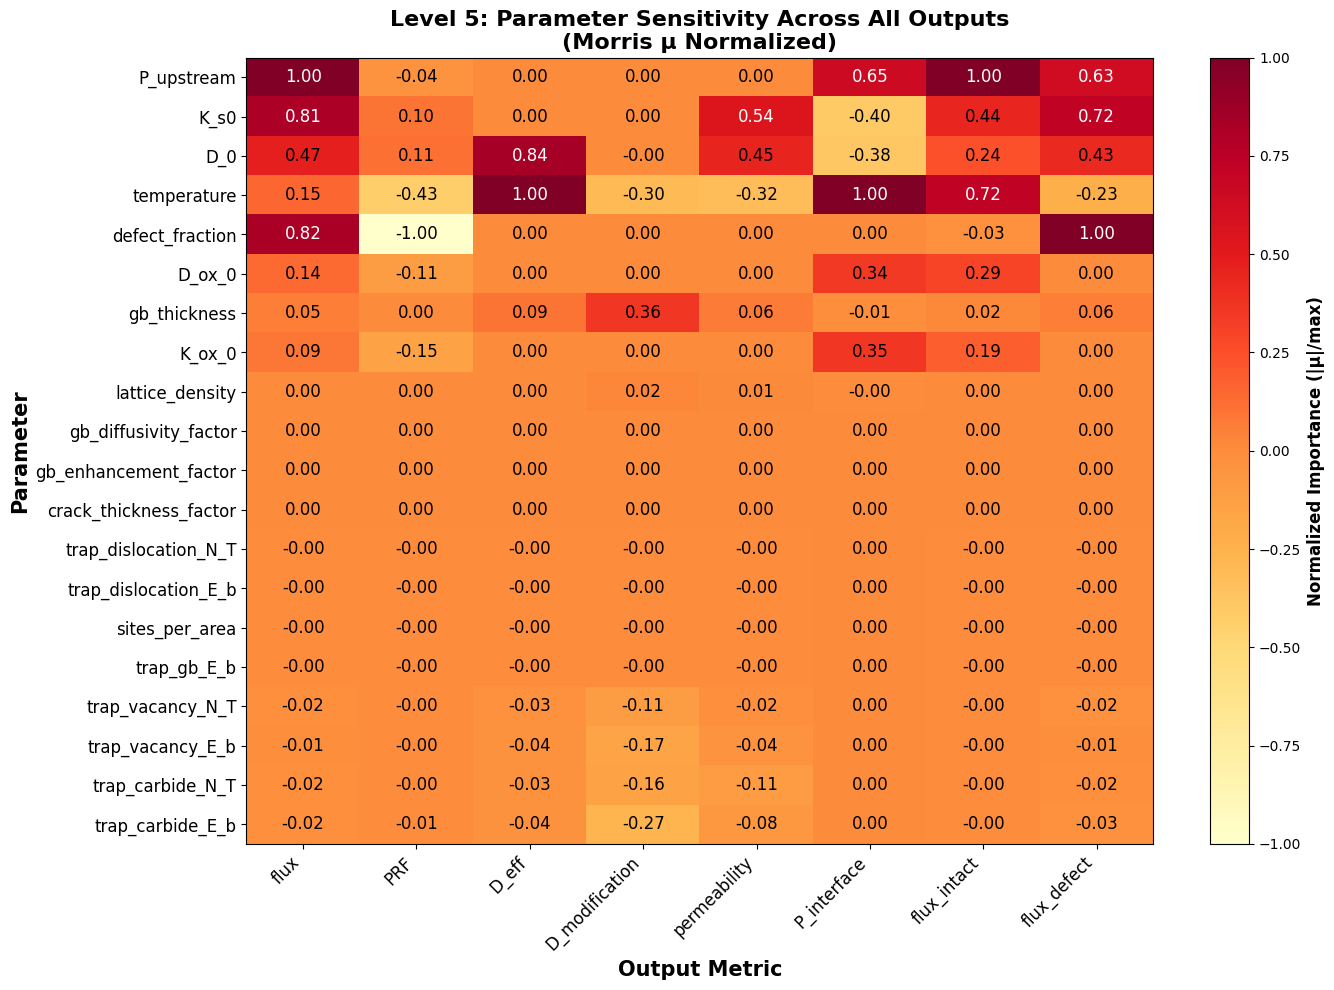

In [9]:
# =============================================================================
# HEATMAP: Parameter Importance Across All Outputs
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Get top 20 parameters for visualization
top_20 = df_all.head(20)

# Extract normalized values for heatmap
heatmap_data = top_20[[f'μ_{m}_norm' for m in VALID_OUTPUT_METRICS_L5]].values
param_labels = top_20['Parameter'].tolist()
output_labels = VALID_OUTPUT_METRICS_L5

fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')

# Labels
ax.set_xticks(np.arange(len(output_labels)))
ax.set_yticks(np.arange(len(param_labels)))
ax.set_xticklabels(output_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(param_labels, fontsize=12)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Importance (|μ|/max)', fontsize=12, fontweight='bold')

# Annotate cells with values
for i in range(len(param_labels)):
    for j in range(len(output_labels)):
        val = heatmap_data[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=12)

ax.set_title('Level 5: Parameter Sensitivity Across All Outputs\n(Morris μ Normalized)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Output Metric', fontsize=15, fontweight='bold')
ax.set_ylabel('Parameter', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

# Sobol Analysis


Top 10 parameters for focused Sobol analysis:

    1. temperature               (avg importance: 0.780)
    2. E_D                       (avg importance: 0.540)
    3. H_s                       (avg importance: 0.511)
    4. D_0                       (avg importance: 0.412)
    5. K_s0                      (avg importance: 0.319)
    6. E_D_ox                    (avg importance: 0.253)
    7. P_upstream                (avg importance: 0.253)
    8. defect_fraction           (avg importance: 0.245)
    9. H_sol_ox                  (avg importance: 0.235)
   10. grain_size                (avg importance: 0.197)

In [10]:
# =============================================================================
# CREATE FOCUSED RANGES FOR SOBOL (Top 10 from Morris Heatmap)
# =============================================================================

# top_10 already exists from the ranking cell above
SOBOL_FOCUSED_RANGES = {param: SUGGESTED_RANGES_LEVEL5[param] for param in top_10}

print("="*70)
print("FOCUSED PARAMETER RANGES FOR SOBOL (Top 10 from Heatmap)")
print("="*70)
for i, (param, bounds) in enumerate(SOBOL_FOCUSED_RANGES.items(), 1):
    importance = df_all[df_all['Parameter'] == param]['Avg_Importance'].values[0]
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]  (μ={importance:.3f})")
print("="*70)

FOCUSED PARAMETER RANGES FOR SOBOL (Top 10 from Heatmap)
   1. P_upstream               : [1.00e+03, 1.00e+06]  (μ=0.404)
   2. K_s0                     : [1.00e-10, 1.00e-07]  (μ=0.277)
   3. D_0                      : [1.00e-08, 1.00e-05]  (μ=0.269)
   4. temperature              : [5.73e+02, 1.27e+03]  (μ=0.198)
   5. defect_fraction          : [1.00e-04, 1.00e-01]  (μ=0.099)
   6. D_ox_0                   : [1.00e-08, 1.00e-04]  (μ=0.083)
   7. gb_thickness             : [3.00e-10, 1.00e-09]  (μ=0.079)
   8. K_ox_0                   : [1.00e-06, 1.00e-02]  (μ=0.060)
   9. lattice_density          : [8.00e+28, 1.20e+29]  (μ=0.006)
  10. gb_diffusivity_factor    : [1.00e+00, 1.00e+02]  (μ=0.000)


In [11]:
# =============================================================================
# SOBOL ANALYSIS: TOP 10 PARAMETERS (from Morris screening)
# =============================================================================
# Set random seeds for reproducibility


sobol_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'#'*70}")
    print(f"# Running Sobol for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = sobol_sensitivity_level5(
        SOBOL_FOCUSED_RANGES,  # Use focused ranges from Morris top 10
        N_samples=1024,              # Samples (total = N × (2D + 2) = 22,528)
        output_metric=output_metric
        
        
    )
  
    sobol_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }

print("\n" + "="*70)
print("✓ Sobol analysis complete for all output metrics!")
print("="*70)


######################################################################
# Running Sobol for: flux
######################################################################

SOBOL SENSITIVITY ANALYSIS - LEVEL 5 (Complete Hierarchical Model)
Running 22528 Sobol samples (N_base=1024, 10 params)
Parameters: P_upstream, K_s0, D_0, temperature, defect_fraction, D_ox_0, gb_thickness, K_ox_0, lattice_density, gb_diffusivity_factor
Output metric: flux
Second-order interactions: Yes
⏳ This may take a while...



/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1951: UserWarning: GB traps already in trap_list, not adding automatically
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.01×) and trapping (1.00×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 809.9 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.02×) and trapping (1.00×) nearly cancel. Small parameter changes could significantly affect resul

  Completed 2252/22528 samples (10%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 785.3 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 725.1 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 610.3 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 637.6 K is far outside dat

  Completed 4504/22528 samples (20%)


...

  Completed 15764/22528 samples (70%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 721.7 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 787.3 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 754.5 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Tempe

  Completed 18016/22528 samples (80%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 657.4 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 832.4 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 736.7 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 824.2 K is outside data ra

  Completed 20268/22528 samples (90%)
  Completed 22520/22528 samples (100%)
  Completed 22528/22528 samples (100%)

✓ Sobol analysis complete
  Output range: [8.39e-15, 7.03e-09]
  Output span: 837832.2× variation

  Parameter                       S1       ST    ST-S1
  ------------------------- -------- -------- --------
  temperature                  0.427    0.725    0.298
  P_upstream                   0.055    0.178    0.123
  K_s0                         0.033    0.172    0.139
  D_0                          0.044    0.147    0.103
  defect_fraction              0.038    0.107    0.068
  K_ox_0                      -0.001    0.063    0.064
  D_ox_0                      -0.006    0.049    0.055
  gb_thickness                -0.000    0.000    0.000
  lattice_density             -0.000    0.000    0.000
  gb_diffusivity_factor        0.000    0.000    0.000

  Sum(S1) = 0.590 (should be ~1 if additive)
  Sum(ST) = 1.441 (>1 indicates interactions)

  Top parameter interactions (S


OUTPUT: flux


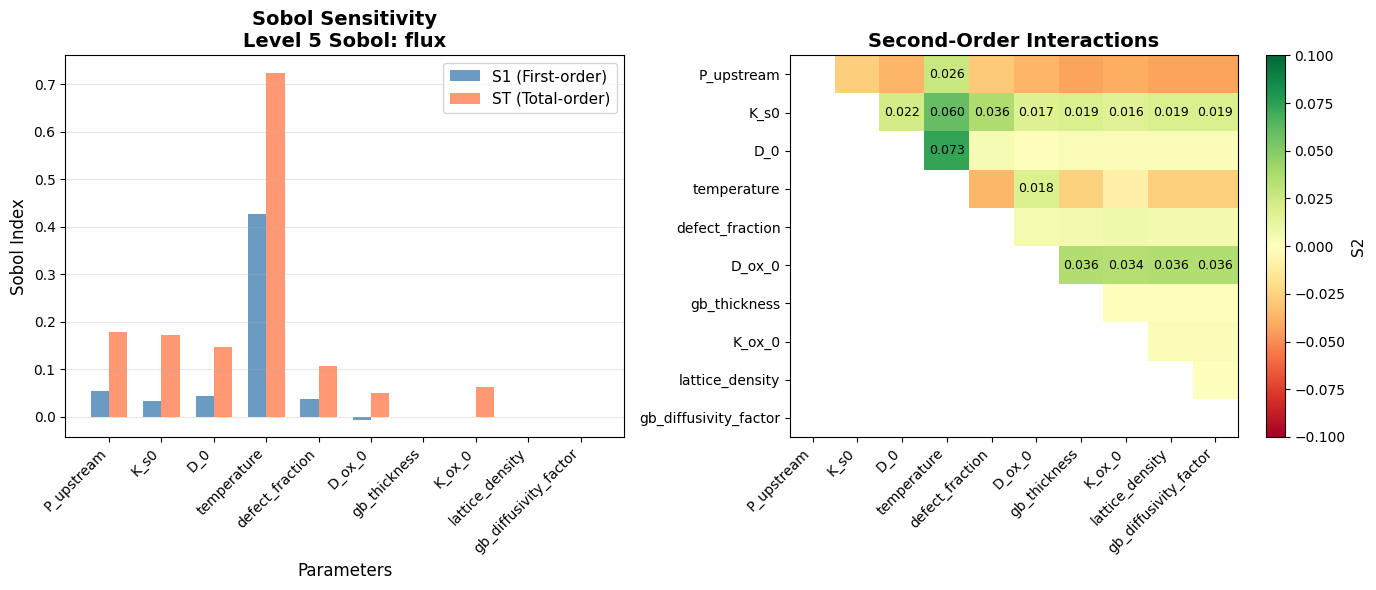


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: flux
            Parameter        S1  S1_conf           ST      ST_conf  Interactions
           P_upstream  0.055010 0.036989 1.782969e-01 9.283622e-02      0.123287
                 K_s0  0.032874 0.025763 1.720395e-01 7.325548e-02      0.139166
                  D_0  0.043520 0.020011 1.468472e-01 3.784176e-02      0.103327
          temperature  0.427153 0.178514 7.247573e-01 1.510590e-01      0.297605
      defect_fraction  0.038310 0.027568 1.065028e-01 4.425908e-02      0.068193
               D_ox_0 -0.005952 0.026674 4.904173e-02 2.841000e-02      0.054994
         gb_thickness -0.000066 0.000107 1.221524e-06 5.752761e-07      0.000067
               K_ox_0 -0.000700 0.010439 6.346772e-02 3.971025e-02      0.064168
      lattice_density -0.000005 0.000008 3.867932e-09 2.390454e-09      0.000005
gb_diffusivity_factor  0.000000 0.000000 0.000000e+00 0.000000e+00      0.000000

Interpretation:
  S1 : First-order effect (direct influence

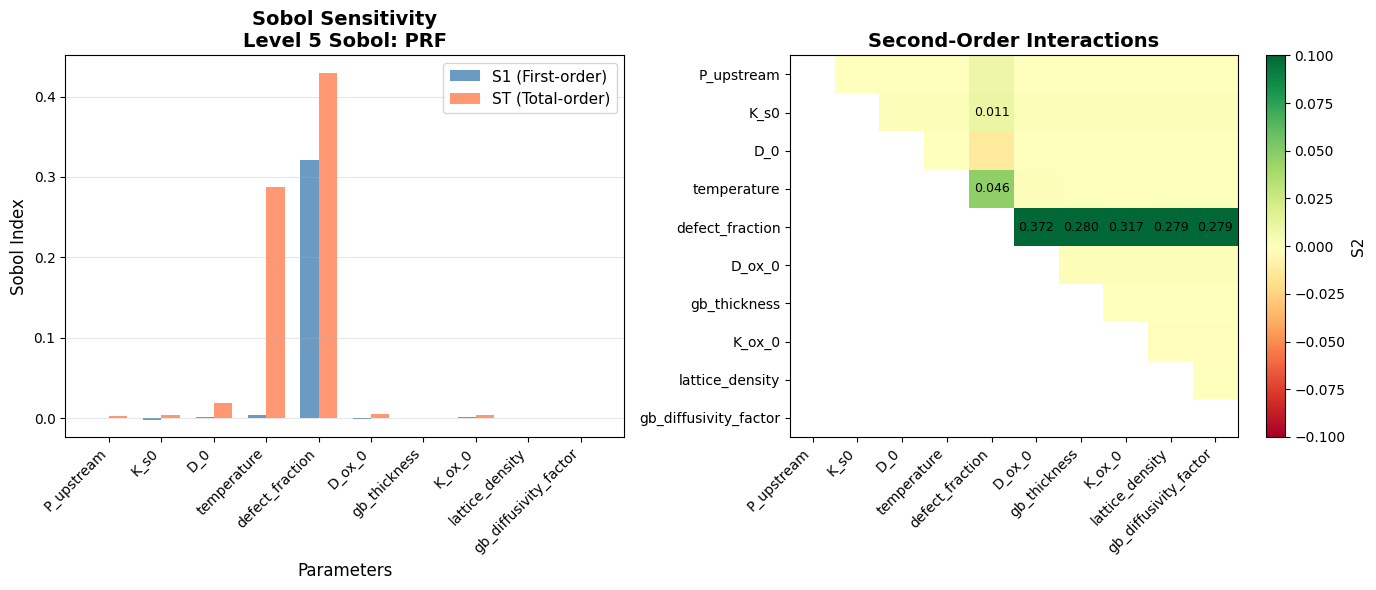


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: PRF
            Parameter            S1      S1_conf           ST      ST_conf  Interactions
           P_upstream -9.737077e-05 1.296624e-03 3.112207e-03 7.456871e-03  3.209578e-03
                 K_s0 -1.968255e-03 2.785517e-03 3.758608e-03 7.659104e-03  5.726864e-03
                  D_0  9.280393e-04 2.385183e-03 1.835923e-02 4.870015e-02  1.743119e-02
          temperature  3.733417e-03 1.197932e-02 2.871438e-01 6.364327e-01  2.834104e-01
      defect_fraction  3.216764e-01 3.168611e-01 4.298245e-01 5.484399e-01  1.081480e-01
               D_ox_0 -6.852922e-04 1.331649e-03 5.591076e-03 1.202632e-02  6.276368e-03
         gb_thickness -3.734880e-06 5.880911e-06 7.510122e-08 2.080994e-07  3.809982e-06
               K_ox_0  1.746338e-03 4.091504e-03 4.325037e-03 1.165324e-02  2.578699e-03
      lattice_density  5.328698e-08 1.029679e-07 2.607180e-11 7.074606e-11 -5.326091e-08
gb_diffusivity_factor  0.000000e+00 0.000000e+00 0.000000e+00 

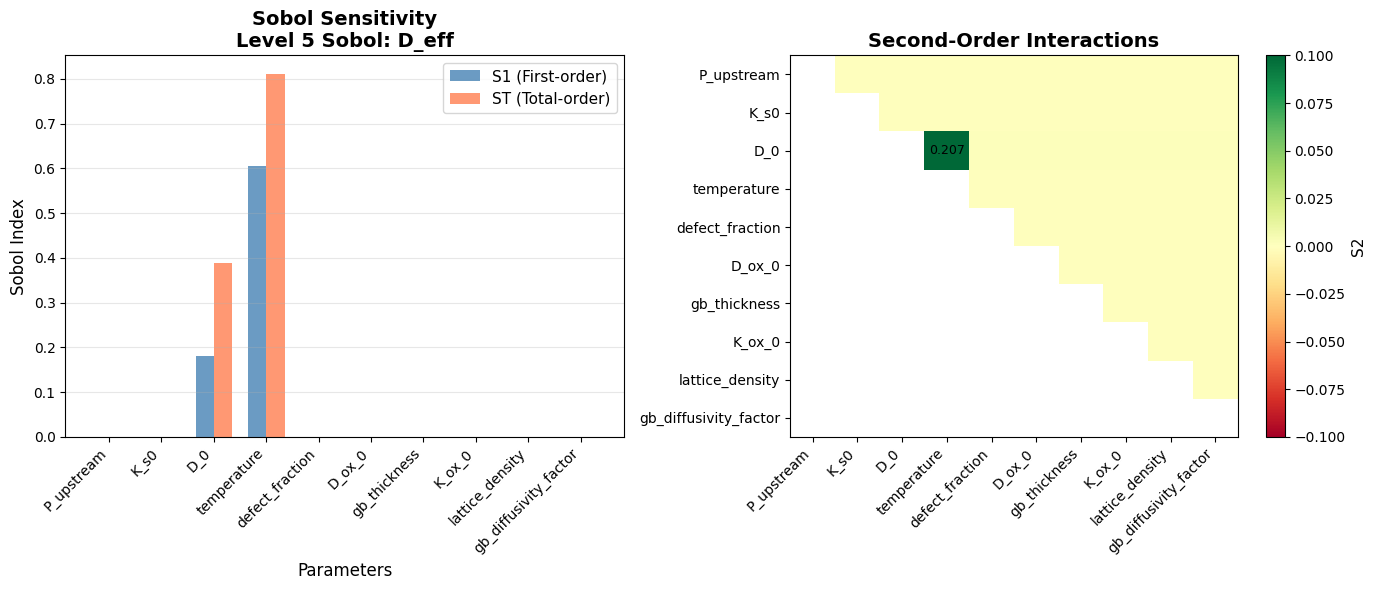


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: D_eff
            Parameter           S1  S1_conf           ST      ST_conf  Interactions
           P_upstream 0.000000e+00 0.000000 0.000000e+00 0.000000e+00  0.000000e+00
                 K_s0 0.000000e+00 0.000000 0.000000e+00 0.000000e+00  0.000000e+00
                  D_0 1.809054e-01 0.051215 3.892258e-01 6.056533e-02  2.083204e-01
          temperature 6.054581e-01 0.093054 8.120882e-01 8.744364e-02  2.066301e-01
      defect_fraction 0.000000e+00 0.000000 0.000000e+00 0.000000e+00  0.000000e+00
               D_ox_0 0.000000e+00 0.000000 0.000000e+00 0.000000e+00  0.000000e+00
         gb_thickness 1.102616e-05 0.000100 1.447298e-06 3.010954e-07 -9.578865e-06
               K_ox_0 0.000000e+00 0.000000 0.000000e+00 0.000000e+00  0.000000e+00
      lattice_density 8.813158e-07 0.000003 9.231111e-10 1.453401e-10 -8.803926e-07
gb_diffusivity_factor 0.000000e+00 0.000000 0.000000e+00 0.000000e+00  0.000000e+00

Interpretation:
  S1 : Fi

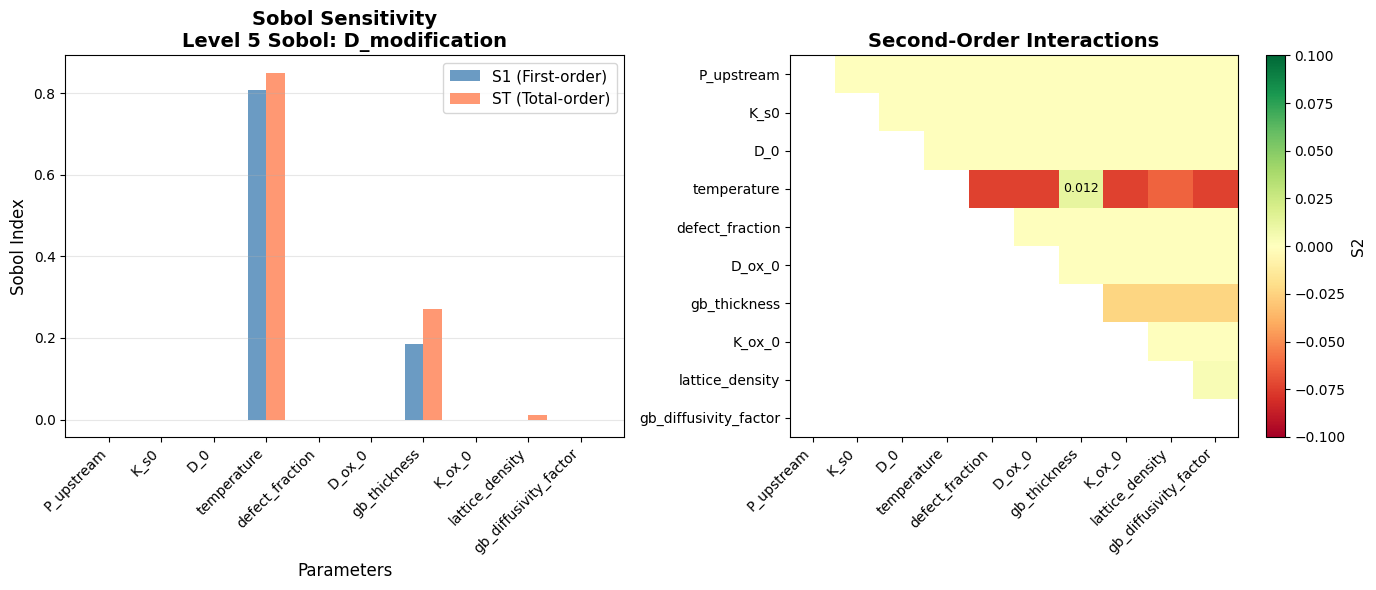


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: D_modification
            Parameter            S1      S1_conf           ST      ST_conf  Interactions
           P_upstream  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
                 K_s0  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
                  D_0 -6.448688e-16 1.416013e-15 2.536754e-28 2.906561e-29  6.448688e-16
          temperature  8.082100e-01 9.159194e-02 8.500581e-01 6.785722e-02  4.184810e-02
      defect_fraction  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
               D_ox_0  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
         gb_thickness  1.853894e-01 4.248038e-02 2.703121e-01 3.457478e-02  8.492267e-02
               K_ox_0  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
      lattice_density -5.444650e-05 8.964921e-03 1.207803e-02 3.460336e-03  1.213248e-02
gb_diffusivity_factor  0.000000e+00 0.000000e+00 0.

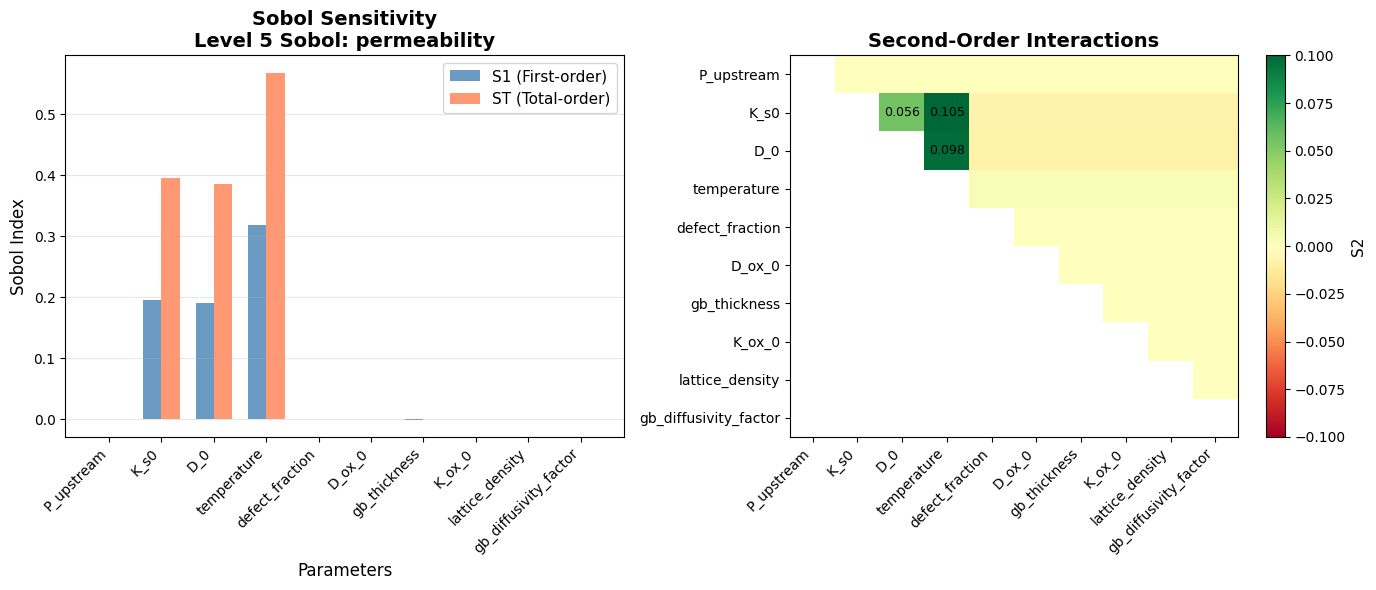


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: permeability
            Parameter        S1  S1_conf           ST      ST_conf  Interactions
           P_upstream  0.000000 0.000000 0.000000e+00 0.000000e+00      0.000000
                 K_s0  0.196369 0.053401 3.955439e-01 7.813285e-02      0.199175
                  D_0  0.191477 0.049064 3.861777e-01 8.060002e-02      0.194700
          temperature  0.317797 0.071029 5.679678e-01 9.332368e-02      0.250171
      defect_fraction  0.000000 0.000000 0.000000e+00 0.000000e+00      0.000000
               D_ox_0  0.000000 0.000000 0.000000e+00 0.000000e+00      0.000000
         gb_thickness -0.000170 0.000191 4.744176e-06 1.481768e-06      0.000174
               K_ox_0  0.000000 0.000000 0.000000e+00 0.000000e+00      0.000000
      lattice_density  0.000001 0.000009 1.197639e-08 4.096620e-09     -0.000001
gb_diffusivity_factor  0.000000 0.000000 0.000000e+00 0.000000e+00      0.000000

Interpretation:
  S1 : First-order effect (direct i

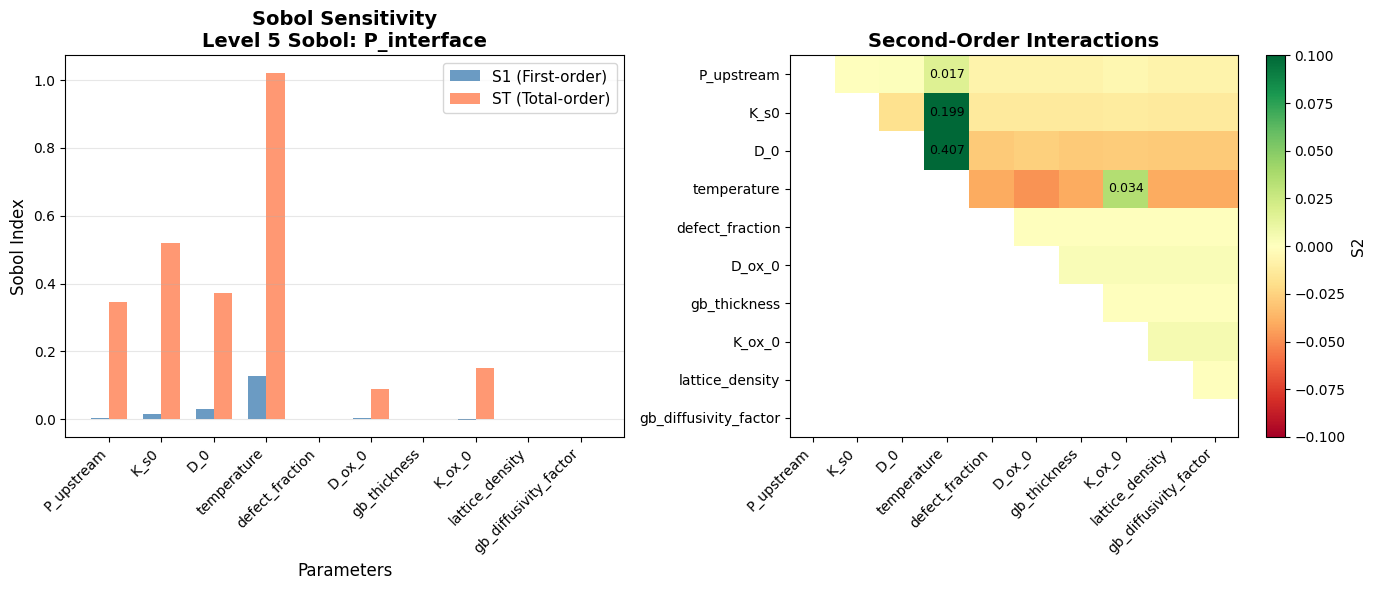


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: P_interface
            Parameter            S1      S1_conf           ST      ST_conf  Interactions
           P_upstream  4.106177e-03 9.289655e-03 3.465570e-01 2.480129e-01  3.424508e-01
                 K_s0  1.536042e-02 2.915091e-02 5.197398e-01 5.483396e-01  5.043794e-01
                  D_0  2.968662e-02 5.124166e-02 3.723061e-01 2.800831e-01  3.426195e-01
          temperature  1.259840e-01 1.589532e-01 1.021845e+00 6.473256e-01  8.958608e-01
      defect_fraction  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
               D_ox_0  2.324715e-03 4.101178e-03 8.890726e-02 6.918007e-02  8.658255e-02
         gb_thickness  6.869477e-08 3.127354e-06 5.328156e-08 6.904232e-08 -1.541321e-08
               K_ox_0 -1.404808e-03 6.172034e-03 1.498744e-01 1.624468e-01  1.512792e-01
      lattice_density -1.768185e-07 2.218862e-07 1.184770e-10 1.734752e-10  1.769370e-07
gb_diffusivity_factor  0.000000e+00 0.000000e+00 0.000

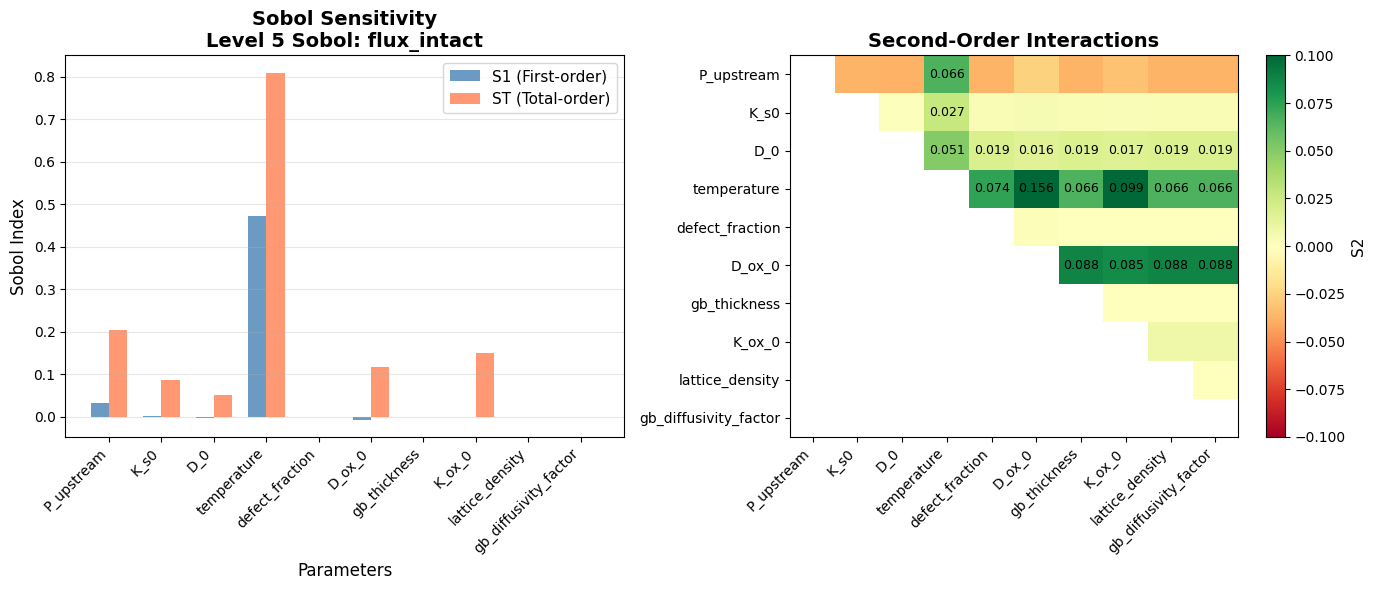


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: flux_intact
            Parameter            S1      S1_conf           ST      ST_conf  Interactions
           P_upstream  3.188177e-02 3.776308e-02 2.048476e-01 1.566684e-01  1.729659e-01
                 K_s0  2.663557e-03 5.615964e-03 8.561860e-02 1.080891e-01  8.295505e-02
                  D_0 -1.769840e-03 6.588660e-03 5.165126e-02 4.642706e-02  5.342110e-02
          temperature  4.727135e-01 2.542130e-01 8.097605e-01 1.616565e-01  3.370471e-01
      defect_fraction -2.974583e-04 1.295169e-03 6.758057e-04 5.412281e-04  9.732640e-04
               D_ox_0 -6.409230e-03 5.120649e-02 1.168407e-01 8.014407e-02  1.232499e-01
         gb_thickness -9.843558e-07 2.815266e-06 5.914242e-10 4.481475e-10  9.849472e-07
               K_ox_0 -7.240464e-04 1.147038e-02 1.512103e-01 1.038539e-01  1.519343e-01
      lattice_density -3.332498e-08 8.655765e-08 8.173483e-13 8.442743e-13  3.332579e-08
gb_diffusivity_factor  0.000000e+00 0.000000e+00 0.000

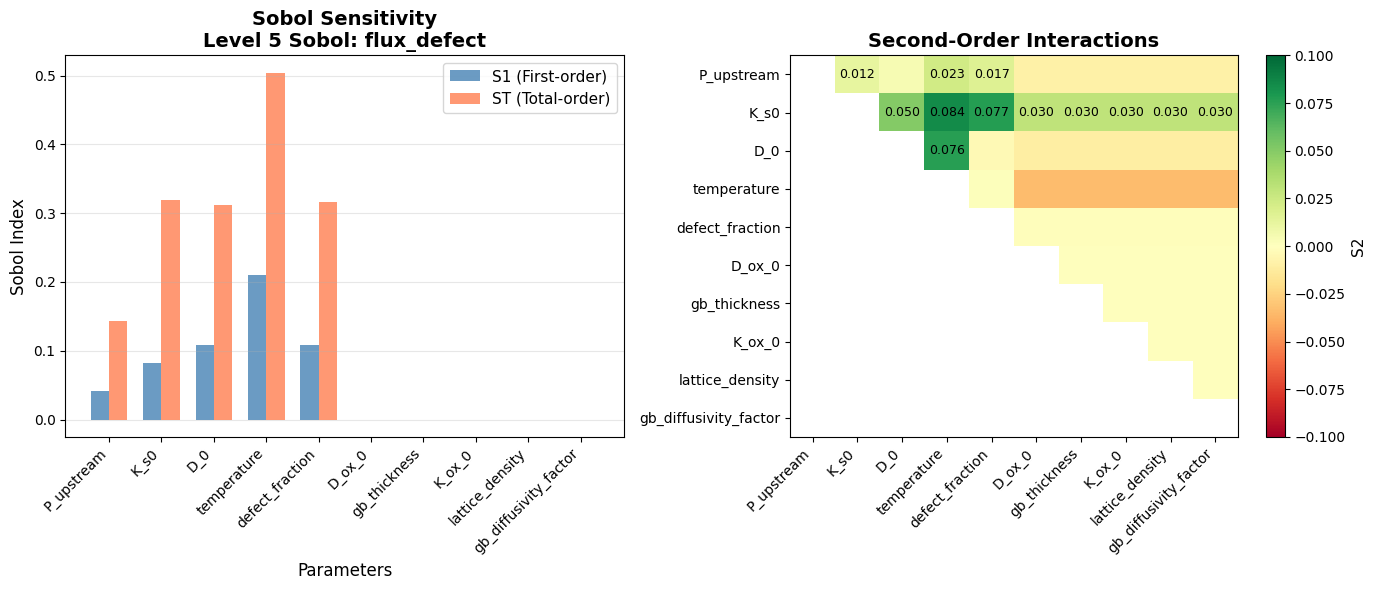


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: flux_defect
            Parameter        S1  S1_conf           ST      ST_conf  Interactions
           P_upstream  0.042192 0.027454 1.431611e-01 4.500752e-02      0.100969
                 K_s0  0.082883 0.051244 3.191407e-01 1.056964e-01      0.236258
                  D_0  0.108961 0.037233 3.120776e-01 8.164331e-02      0.203117
          temperature  0.209855 0.077652 5.043062e-01 1.361852e-01      0.294451
      defect_fraction  0.107773 0.046982 3.161071e-01 9.705805e-02      0.208334
               D_ox_0  0.000000 0.000000 0.000000e+00 0.000000e+00      0.000000
         gb_thickness -0.000058 0.000122 3.479907e-06 1.327382e-06      0.000062
               K_ox_0  0.000000 0.000000 0.000000e+00 0.000000e+00      0.000000
      lattice_density -0.000008 0.000014 1.102340e-08 6.238889e-09      0.000008
gb_diffusivity_factor  0.000000 0.000000 0.000000e+00 0.000000e+00      0.000000

Interpretation:
  S1 : First-order effect (direct in

In [12]:
# =============================================================================
# PLOT SOBOL RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = sobol_results[output_metric]['Si']
    problem = sobol_results[output_metric]['problem']
    
    plot_sobol_results(Si, problem, f'Level 5 Sobol: {output_metric}')

## Level 5L6 Sensitivity Analysis: Full System with Surface Kinetics (31 Parameters)

Extends Level 5 by adding surface dissociation kinetics (k_diss, K_eq) and their Arrhenius parameters.
New output metrics: frac_surface, frac_oxide, frac_metal (flux-weighted), theta (surface coverage).

In [ ]:
from SALib.sample import morris as morris_sampler
from SALib.analyze import morris as morris_analyzer
from SALib.plotting import morris as morris_plotter
from SALib.sample import saltelli as sobol_sampler
from SALib.analyze import sobol as sobol_analyzer
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
import importlib
import numpy as np
import random
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
import validation.sensitivity_level1 as sens_module_l6
importlib.reload(sens_module_l6)

# =============================================================================
# LEVEL 6 SENSITIVITY ANALYSIS SETUP
# =============================================================================
from validation.sensitivity_level1 import (
    morris_sensitivity_level5L6,
    sobol_sensitivity_level5L6,
    plot_morris_results,
    plot_sobol_results,
    SUGGESTED_RANGES_LEVEL5L6,
    DEFAULT_PARAMS_LEVEL5L6,
    VALID_OUTPUT_METRICS_L5L6
)

# Check what we have
print(f"Number of parameters in SUGGESTED_RANGES_LEVEL5L6: {len(SUGGESTED_RANGES_LEVEL5L6)}")
print(f"\nParameters:")
for i, (param, bounds) in enumerate(SUGGESTED_RANGES_LEVEL5L6.items(), 1):
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]")

print(f"\nValid output metrics: {VALID_OUTPUT_METRICS_L5L6}")

In [ ]:
# =============================================================================
# MORRIS ANALYSIS: ALL VALID OUTPUT METRICS
# =============================================================================
# Run Morris screening for each output metric and store results

morris_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'#'*70}")
    print(f"# Running Morris for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = morris_sensitivity_level5L6(
        SUGGESTED_RANGES_LEVEL5L6,
        N_trajectories=500,
        num_levels=4,
        seed=42,
        output_metric=output_metric
        
    )
    
    morris_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }
    
print("\n" + "="*70)
print("✓ Morris analysis complete for all output metrics!")
print("="*70)

In [ ]:
morris_results

In [ ]:
# =============================================================================
# PLOT MORRIS RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = morris_results[output_metric]['Si']
    problem = morris_results[output_metric]['problem']
    
    plot_morris_results(Si, problem, f'Level 6: {output_metric}')

In [ ]:
# =============================================================================
# PARAMETER IMPORTANCE RANKING ACROSS ALL 11 OUTPUTS
# =============================================================================
import pandas as pd

param_names = morris_results['flux']['problem']['names']

# Build DataFrame with μ for each output
df_all = pd.DataFrame({'Parameter': param_names})

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    df_all[f'μ_{output_metric}'] = morris_results[output_metric]['Si']['mu']

# Normalize each column
for output_metric in VALID_OUTPUT_METRICS_L5L6:
    col = f'μ_{output_metric}'
    max_val = df_all[col].abs().max()
    if max_val > 0:
        df_all[f'{col}_norm'] = df_all[col] / max_val
    else:
        df_all[f'{col}_norm'] = 0

# Average normalized importance across all outputs
norm_cols = [f'μ_{m}_norm' for m in VALID_OUTPUT_METRICS_L5L6]
df_all['Avg_Importance'] = df_all[norm_cols].mean(axis=1)
df_all = df_all.sort_values('Avg_Importance', ascending=False)

# Display summary
print("="*100)
print("PARAMETER IMPORTANCE RANKING (Morris μ - All 11 Outputs)")
print("="*100)
display_cols = ['Parameter'] + [f'μ_{m}' for m in VALID_OUTPUT_METRICS_L5L6] + ['Avg_Importance']
print(df_all[display_cols].to_string(index=False))
print("="*100)

# Top 10 for Sobol
top_10 = df_all.head(10)['Parameter'].tolist()
print(f"\n→ Top 10 parameters for focused Sobol analysis:")
for i, p in enumerate(top_10, 1):
    importance = df_all[df_all['Parameter'] == p]['Avg_Importance'].values[0]
    print(f"   {i:2d}. {p:<25s} (avg importance: {importance:.3f})")

In [ ]:
# =============================================================================
# HEATMAP: Parameter Importance Across All Outputs
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Get top 20 parameters for visualization
top_20 = df_all.head(20)

# Extract normalized values for heatmap
heatmap_data = top_20[[f'μ_{m}_norm' for m in VALID_OUTPUT_METRICS_L5L6]].values
param_labels = top_20['Parameter'].tolist()
output_labels = VALID_OUTPUT_METRICS_L5L6

fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')

# Labels
ax.set_xticks(np.arange(len(output_labels)))
ax.set_yticks(np.arange(len(param_labels)))
ax.set_xticklabels(output_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(param_labels, fontsize=12)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Importance (|μ|/max)', fontsize=12, fontweight='bold')

# Annotate cells with values
for i in range(len(param_labels)):
    for j in range(len(output_labels)):
        val = heatmap_data[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=12)

ax.set_title('Level 5L6: Parameter Sensitivity Across All Outputs\n(Morris μ Normalized)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Output Metric', fontsize=15, fontweight='bold')
ax.set_ylabel('Parameter', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# CREATE FOCUSED RANGES FOR SOBOL (Top 10 from Morris Heatmap)
# =============================================================================

# top_10 already exists from the ranking cell above
SOBOL_FOCUSED_RANGES = {param: SUGGESTED_RANGES_LEVEL5L6[param] for param in top_10}

print("="*70)
print("FOCUSED PARAMETER RANGES FOR SOBOL (Top 10 from Heatmap)")
print("="*70)
for i, (param, bounds) in enumerate(SOBOL_FOCUSED_RANGES.items(), 1):
    importance = df_all[df_all['Parameter'] == param]['Avg_Importance'].values[0]
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]  (μ={importance:.3f})")
print("="*70)

In [ ]:
# =============================================================================
# SOBOL ANALYSIS: TOP 10 PARAMETERS (from Morris screening)
# =============================================================================
# Set random seeds for reproducibility


sobol_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'#'*70}")
    print(f"# Running Sobol for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = sobol_sensitivity_level5L6(
        SOBOL_FOCUSED_RANGES,  # Use focused ranges from Morris top 10
        N_samples=1024,              # Samples (total = N × (2D + 2) = 22,528)
        output_metric=output_metric
        
        
    )
  
    sobol_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }

print("\n" + "="*70)
print("✓ Sobol analysis complete for all output metrics!")
print("="*70)

In [ ]:
# =============================================================================
# PLOT SOBOL RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = sobol_results[output_metric]['Si']
    problem = sobol_results[output_metric]['problem']
    
    plot_sobol_results(Si, problem, f'Level 6 Sobol: {output_metric}')